# More Pandas Practice: Combining Data, Binning, and Pivot Tables

This notebook gives you practice applying the tools from `02_Combining_Dataframes.ipynb`: joining and concatenating DataFrames with `.join()` and `pd.concat()`, binning continuous data into categories with `pd.cut()`, and summarising data with `pd.pivot_table()`. You will work with the red and white wine quality datasets throughout — loading, combining, filtering, and pivoting them to answer realistic data questions.

---

## Starter Code

In [1]:
import matplotlib.pyplot as plt
# Import pandas and load both wine datasets — run this cell first
import pandas as pd
from pygments.lexers import markup

red_df = pd.read_csv('../data/winequality-red.csv', delimiter=';')
white_df = pd.read_csv('../data/winequality-white.csv', delimiter=';')

print('Red wine shape:', red_df.shape)
print('White wine shape:', white_df.shape)

Red wine shape: (1599, 12)
White wine shape: (4898, 12)


---

## Part 1 — Loading and Inspecting

### Challenge 1: Sense-check the data

Use DataFrame attributes and methods to confirm both datasets loaded correctly. Check:

- The number of rows and columns in each

- The data types of the columns

- Whether any columns contain null values

In [2]:
# YOUR CODE HERE
red_df.tail(10)
white_df.tail(10)

print(red_df.info())
print(white_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null 

---

## Part 2 — Filtering by Alcohol Content

### Challenge 2: Flag above-average alcohol

You want to avoid wines with above-average alcohol content. To do this:

1. Find the **mean alcohol content** separately for reds and whites.

2. Create a **boolean `Series`** for each DataFrame indicating whether each row has an alcohol content above the mean.

3. Attach this boolean `Series` to each DataFrame — do it **twice**: once using `.join()` and once using `pd.concat(..., axis=1)`.

4. Filter each DataFrame to return only the rows where alcohol is **above** the mean.

In [3]:
# Step 1: Calculate mean alcohol for each wine type
# YOUR CODE HERE
red_mean = red_df['alcohol'].mean()
white_mean = white_df['alcohol'].mean()

print(red_mean)
print(white_mean)

10.422983114446529
10.514267047774602


In [4]:
# Step 2: Create boolean Series — True where alcohol is above the mean
# YOUR CODE HERE
# red_df.query(f'alcohol > {red_mean}')

red_bool = red_df['alcohol'] > red_mean
white_bool = white_df['alcohol'] > white_mean

red_bool.name = "red_bool"
white_bool.name = "white_bool"
print(red_bool, type(red_bool))
print(white_bool, type(white_bool))
print(white_bool)

0       False
1       False
2       False
3       False
4       False
        ...  
1594     True
1595     True
1596     True
1597    False
1598     True
Name: red_bool, Length: 1599, dtype: bool <class 'pandas.Series'>
0       False
1       False
2       False
3       False
4       False
        ...  
4893     True
4894    False
4895    False
4896     True
4897     True
Name: white_bool, Length: 4898, dtype: bool <class 'pandas.Series'>
0       False
1       False
2       False
3       False
4       False
        ...  
4893     True
4894    False
4895    False
4896     True
4897     True
Name: white_bool, Length: 4898, dtype: bool


In [5]:
# Step 3a: Attach using .join()
# YOUR CODE HERE
red_df.join(red_bool)
white_df.join(white_bool)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,white_bool
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,False
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,False
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,False
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,False
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,True
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,False
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,False
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,True


In [6]:
# Step 3b: Attach using pd.concat(..., axis=1)
# YOUR CODE HERE
red_df = pd.concat([red_df, red_bool], axis=1)
white_df = pd.concat([white_df, white_bool], axis=1)

white_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,white_bool
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,False
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,False
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,False
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,False
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,True
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,False
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,False
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,True


In [53]:
# Step 4: Filter to only rows where alcohol is above the mean
# YOUR CODE HERE
red_above_mean = red_df.query(f'alcohol > {red_mean}')
white_above_mean = white_df.query(f'alcohol > {white_mean}')

---

## Part 3 — Binning by Acidity

### Challenge 3: Bin by fixed acidity

You want to avoid wines with the highest acidity. To do this:

1. Use `pd.cut()` to divide the `fixed acidity` column of each DataFrame into **5 equal-width bins**.

2. Attach the resulting bin `Series` to each original DataFrame — once using `.join()` and once using `pd.concat(..., axis=1)`.

3. Filter each DataFrame to return only rows that are **not** in the top acidity bin.

> Note: equal-width bins divide the *range* of values into equal intervals. They are different from quintiles (equal-count bins).

In [24]:
# Step 1: Create 5 equal-width acidity bins for red and white wines
# YOUR CODE HERE
red_bins = pd.cut(red_df['fixed acidity'], bins=5)
white_bins = pd.cut(white_df['fixed acidity'], bins=5)

red_bins.name = "red_bins"
white_bins.name = "white_bins"

print(red_bins)
print(white_bins)

0        (6.86, 9.12]
1        (6.86, 9.12]
2        (6.86, 9.12]
3       (9.12, 11.38]
4        (6.86, 9.12]
            ...      
1594    (4.589, 6.86]
1595    (4.589, 6.86]
1596    (4.589, 6.86]
1597    (4.589, 6.86]
1598    (4.589, 6.86]
Name: red_bins, Length: 1599, dtype: category
Categories (5, interval[float64, right]): [(4.589, 6.86] < (6.86, 9.12] < (9.12, 11.38] < (11.38, 13.64] < (13.64, 15.9]]
0        (5.88, 7.96]
1        (5.88, 7.96]
2       (7.96, 10.04]
3        (5.88, 7.96]
4        (5.88, 7.96]
            ...      
4893     (5.88, 7.96]
4894     (5.88, 7.96]
4895     (5.88, 7.96]
4896     (3.79, 5.88]
4897     (5.88, 7.96]
Name: white_bins, Length: 4898, dtype: category
Categories (5, interval[float64, right]): [(3.79, 5.88] < (5.88, 7.96] < (7.96, 10.04] < (10.04, 12.12] < (12.12, 14.2]]


In [26]:
# Step 2a: Attach bins using .join()
# YOUR CODE HERE
red_df.join(red_bins)
white_df.join(white_bins)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,white_bool,white_bins
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,False,"(5.88, 7.96]"
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,False,"(5.88, 7.96]"
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,False,"(7.96, 10.04]"
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,False,"(5.88, 7.96]"
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,False,"(5.88, 7.96]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,True,"(5.88, 7.96]"
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,False,"(5.88, 7.96]"
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,False,"(5.88, 7.96]"
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,True,"(3.79, 5.88]"


In [27]:
# Step 2b: Attach bins using pd.concat(..., axis=1)
# YOUR CODE HERE
red_df = pd.concat([red_df, red_bins], axis=1)
white_df = pd.concat([white_df, white_bins], axis=1)

print(red_df)
print(white_df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [58]:
# Step 3: Filter out the top acidity bin from each DataFrame
# YOUR CODE HERE
red_df.groupby('red_bins').count()

top_acid_red = red_bins.unique()[-1]
top_acid_white = white_bins.unique()[-1]

red_bins.value_counts().sort_index()

red_non_top = red_df[red_df['red_bins'] != top_acid_red]
white_non_top = white_df[white_df['white_bins'] != top_acid_white]

---

## Part 4 — Pivot Tables

### Challenge 4: Alcohol by quality — pivot table

You want to understand how avoiding above-average alcohol affects the quality of wines available to you.

Using the **above-average alcohol** subsets from Challenge 2, create a **pivot table** for each wine type showing:

- The **average `alcohol` content** as the value

- **`quality`** as the index

This should give you one row per quality level and the average alcohol content for that group.

In [56]:
# Pivot table for red wines above mean alcohol — average alcohol by quality
# YOUR CODE HERE
pd.pivot_table(
    red_above_mean,
    values='alcohol',
    columns='quality',
    aggfunc='mean',
)

quality,3,4,5,6,7,8
alcohol,10.866667,11.295,11.088686,11.437214,11.708236,12.36875


In [57]:
# Pivot table for white wines above mean alcohol — average alcohol by quality
# YOUR CODE HERE
pd.pivot_table(
    white_above_mean,
    values='alcohol',
    columns='quality',
    aggfunc='mean',
)

quality,3,4,5,6,7,8,9
alcohol,11.525,11.425532,11.211099,11.604366,11.924761,12.139437,12.625


### Challenge 5: Alcohol by quality and acidity bin — pivot table

Now do the same for the **non-top-acidity** subsets from Challenge 3. Create a pivot table for each wine type showing:

- The **average `alcohol` content** as the value

- **`quality`** as the index

- **`fixed acidity` bin** as the columns

This lets you see average alcohol broken down by both quality score and acidity category.

In [62]:
# Pivot table for red wines — average alcohol by quality and acidity bin
# YOUR CODE HERE
pivot_red = pd.pivot_table(
    red_non_top,
    values='alcohol',
    index='quality',
    columns='red_bins',
    aggfunc='mean',
)
pivot_red

red_bins,"(4.589, 6.86]","(6.86, 9.12]","(9.12, 11.38]","(11.38, 13.64]"
quality,,,,
3,9.875000,10.500000,9.150000,9.000000
4,11.006667,9.981667,9.920000,9.966667
5,10.304245,9.773727,9.846429,10.229630
6,11.223529,10.431985,10.687395,10.480952
7,12.195402,11.486413,11.383333,10.809524
8,13.633333,11.937500,11.916667,9.800000


In [63]:
# Pivot table for white wines — average alcohol by quality and acidity bin
# YOUR CODE HERE
pivot_white = pd.pivot_table(
    white_non_top,
    values='alcohol',
    index='quality',
    columns='white_bins',
    aggfunc='mean',
)
pivot_white

white_bins,"(3.79, 5.88]","(5.88, 7.96]","(7.96, 10.04]","(10.04, 12.12]"
quality,,,,
3,9.850000,10.472727,10.540000,9.65
4,10.786364,10.102564,10.126471,9.90
5,10.136635,9.732173,10.176452,9.70
6,10.902765,10.529056,10.635247,9.50
7,12.021405,11.303724,10.988679,NaN
8,12.403030,11.486364,11.080000,NaN
9,NaN,12.625000,10.400000,NaN


---

## Part 5 — Open Exploration

### Challenge 6: Your own question

Set a 10-minute timer. Pick one question about the wine data that interests you and answer it using any combination of the tools from this notebook (filtering, joining, binning, pivot tables, groupby, visualisation). Be ready to explain what you found and why you chose that question.

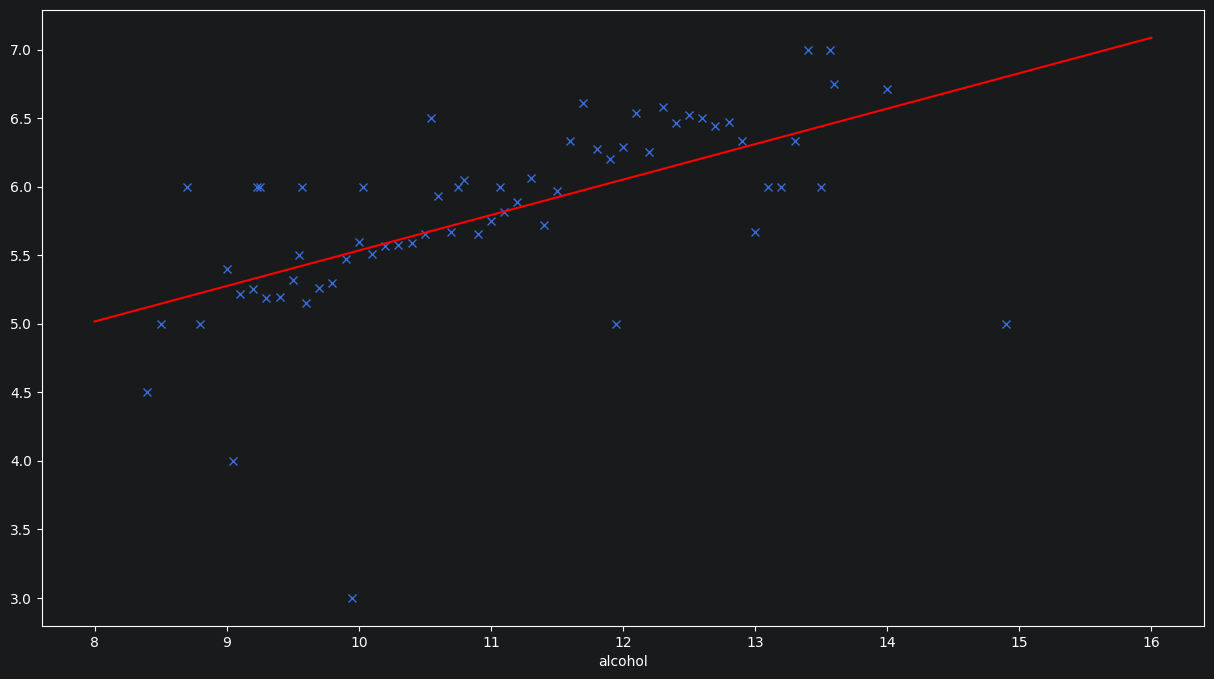

In [108]:
# YOUR CODE HERE
#pivot_white.plot(kind='bar', figsize=(10, 5), ylabel='Acidity', )
from scipy.optimize import curve_fit
import numpy as np

def linear(x, m, n):
    return m*x + n

red_plot = red_df.groupby('alcohol')['quality'].mean()

red_plot.plot(
    figsize=(15, 8),
    marker='x',
    linestyle='',
)
x_values = np.linspace(8, 16)
params = curve_fit(linear, red_plot.index.values, red_plot.values)

plt.plot(x_values, linear(x_values, *params[0]), 'r')

plt.show()